<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-06-25 13:20:25--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  59.3MB/s    in 3.5s    

2025-06-25 13:20:29 (58.1 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


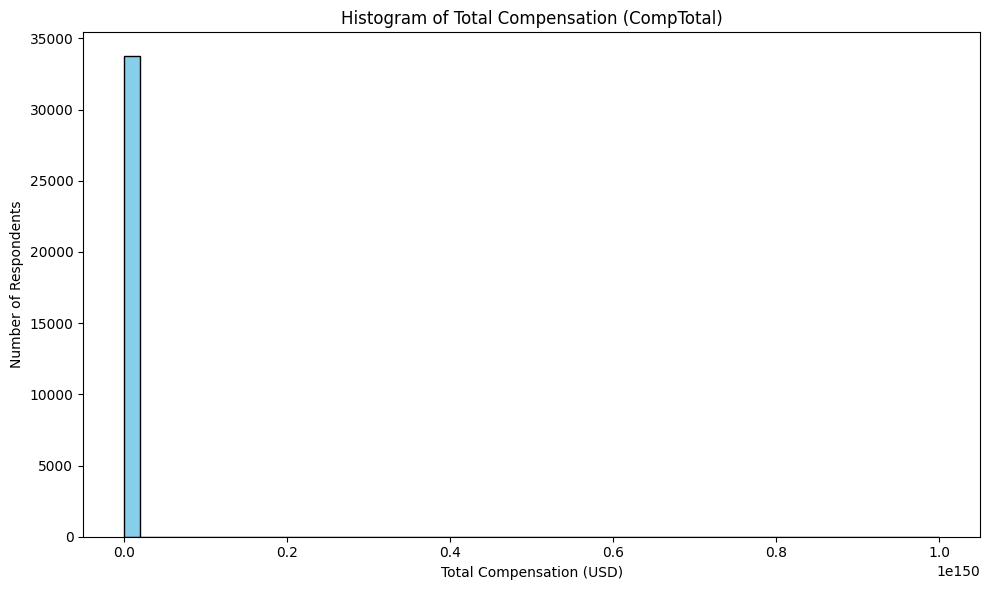

In [19]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Load the dataset from SQLite
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop missing values in CompTotal
comp_total = df['CompTotal'].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(comp_total, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


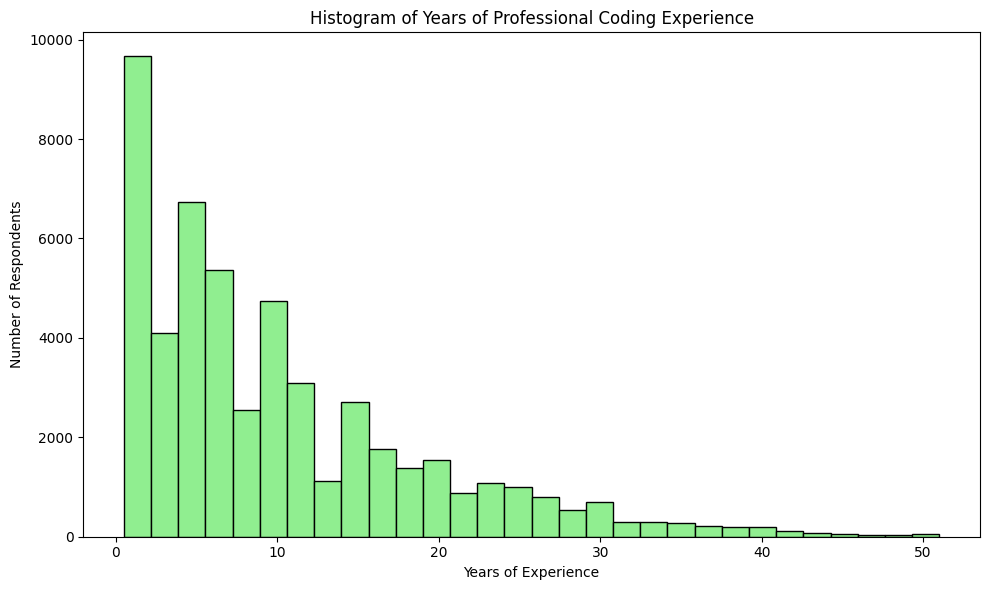

In [11]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Connect to SQLite database and load data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Clean and convert YearsCodePro to numeric
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
}).astype(float)

# Drop missing values
years_exp = df['YearsCodePro'].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(years_exp, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of Years of Professional Coding Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


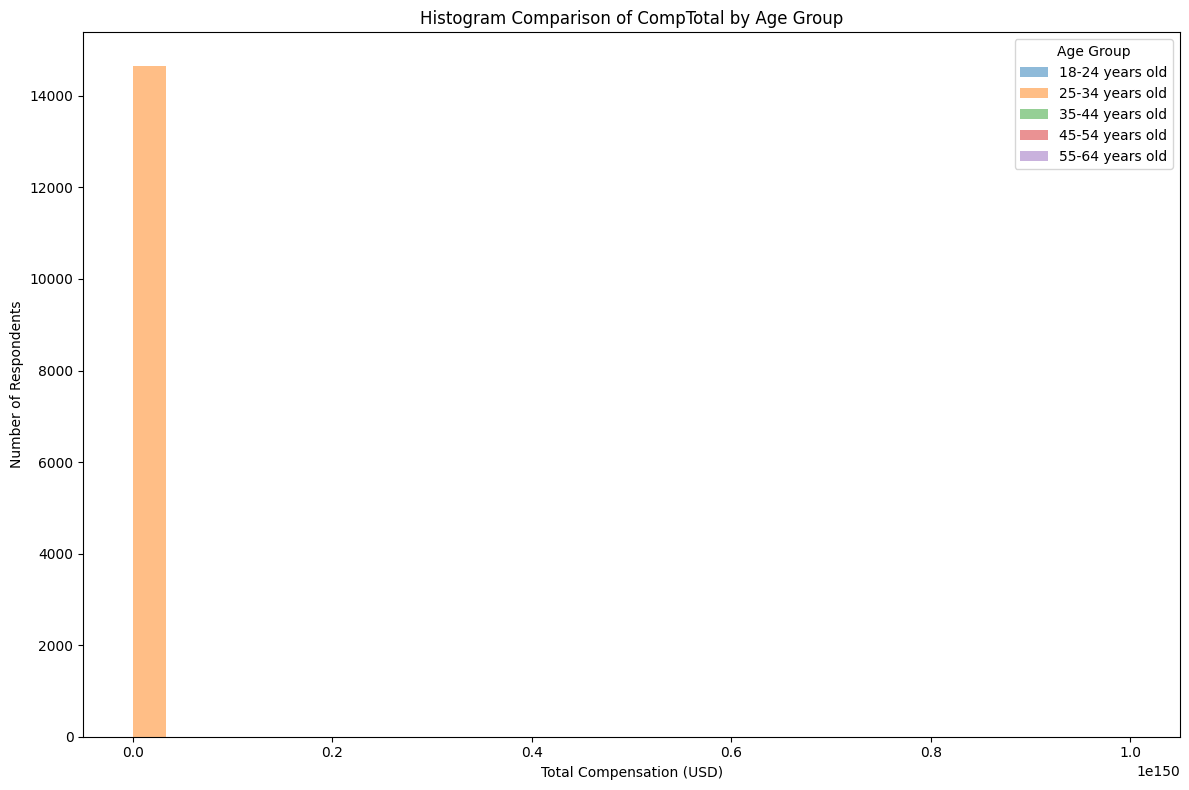

In [12]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Load dataset from SQLite
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop missing values in Age and CompTotal
df = df[['Age', 'CompTotal']].dropna()

# Define the age groups of interest
age_groups = [
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old'
]

# Filter dataset for selected age groups only
df = df[df['Age'].isin(age_groups)]

# Plot histograms for each age group
plt.figure(figsize=(12, 8))
for age_group in age_groups:
    group_data = df[df['Age'] == age_group]['CompTotal']
    plt.hist(group_data, bins=30, alpha=0.5, label=age_group)

plt.title('Histogram Comparison of CompTotal by Age Group')
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


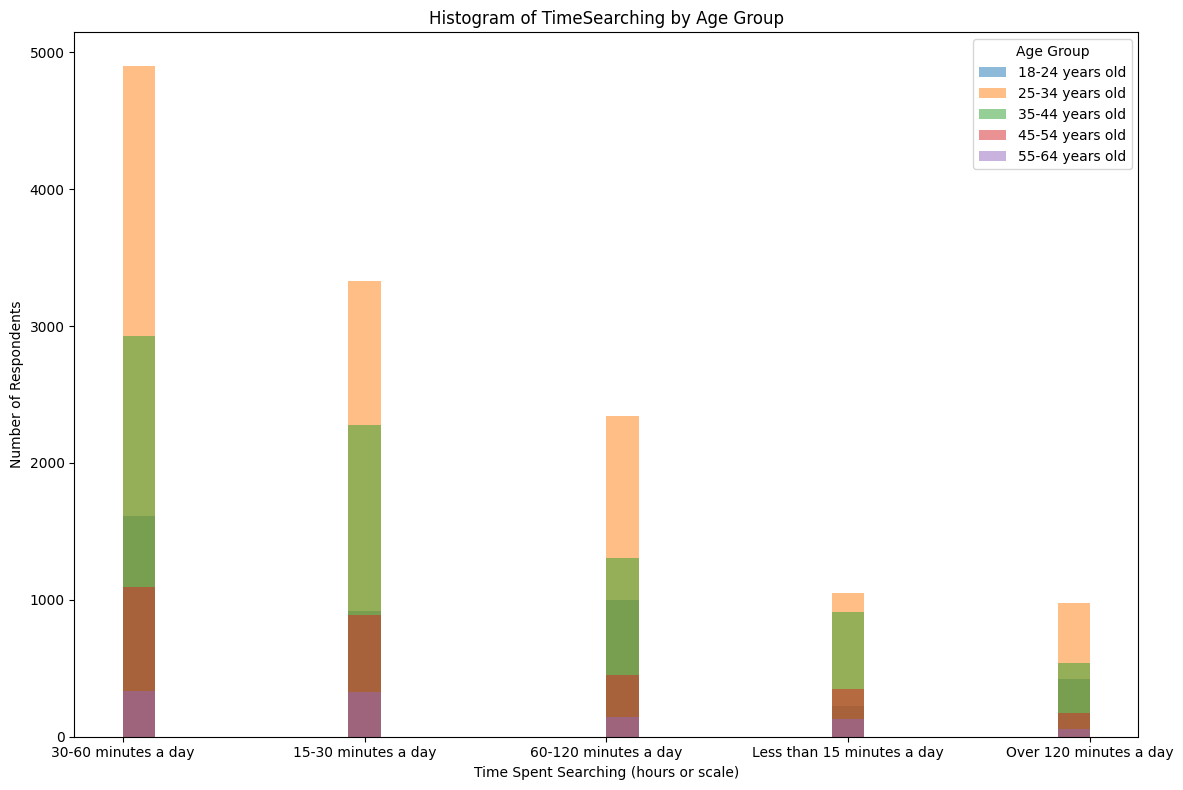

In [13]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Connect to SQLite database and load data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop missing values in Age and TimeSearching
df = df[['Age', 'TimeSearching']].dropna()

# Define age groups to include in the histogram
age_groups = [
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old'
]

# Filter only selected age groups
df = df[df['Age'].isin(age_groups)]

# Plot histograms for TimeSearching by age group
plt.figure(figsize=(12, 8))
for age_group in age_groups:
    group_data = df[df['Age'] == age_group]['TimeSearching']
    plt.hist(group_data, bins=30, alpha=0.5, label=age_group)

plt.title('Histogram of TimeSearching by Age Group')
plt.xlabel('Time Spent Searching (hours or scale)')
plt.ylabel('Number of Respondents')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


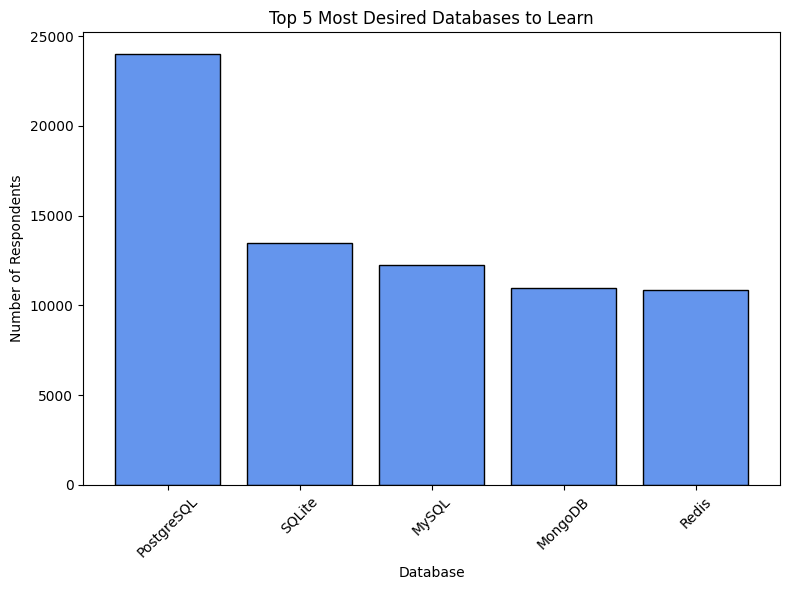

In [14]:
## Write your code here

# Connect to the SQLite database and load data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop missing values in DatabaseWantToWorkWith
df_db = df['DatabaseWantToWorkWith'].dropna()

# Split multiple selections and explode into separate rows
# Assumes entries are separated by semicolons
all_dbs = df_db.str.split(';').explode().str.strip()

# Count frequency of each database
top_dbs = all_dbs.value_counts().nlargest(5)

# Plot histogram
plt.figure(figsize=(8, 6))
plt.bar(top_dbs.index, top_dbs.values, color='cornflowerblue', edgecolor='black')
plt.title('Top 5 Most Desired Databases to Learn')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


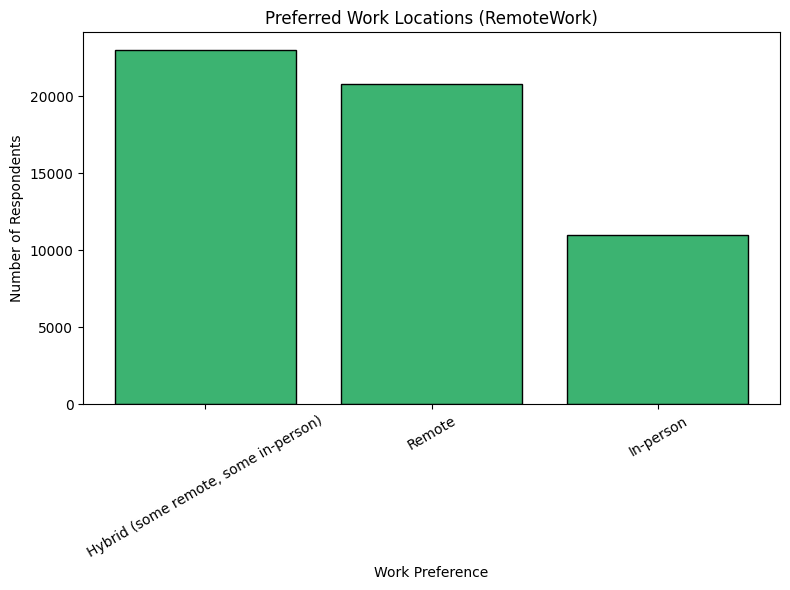

In [15]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Connect to the SQLite database and load data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop missing values in RemoteWork column
remote_work_data = df['RemoteWork'].dropna()

# Count frequency of each work preference
remote_work_counts = remote_work_data.value_counts()

# Plot histogram (bar chart)
plt.figure(figsize=(8, 6))
plt.bar(remote_work_counts.index, remote_work_counts.values, color='mediumseagreen', edgecolor='black')
plt.title('Preferred Work Locations (RemoteWork)')
plt.xlabel('Work Preference')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


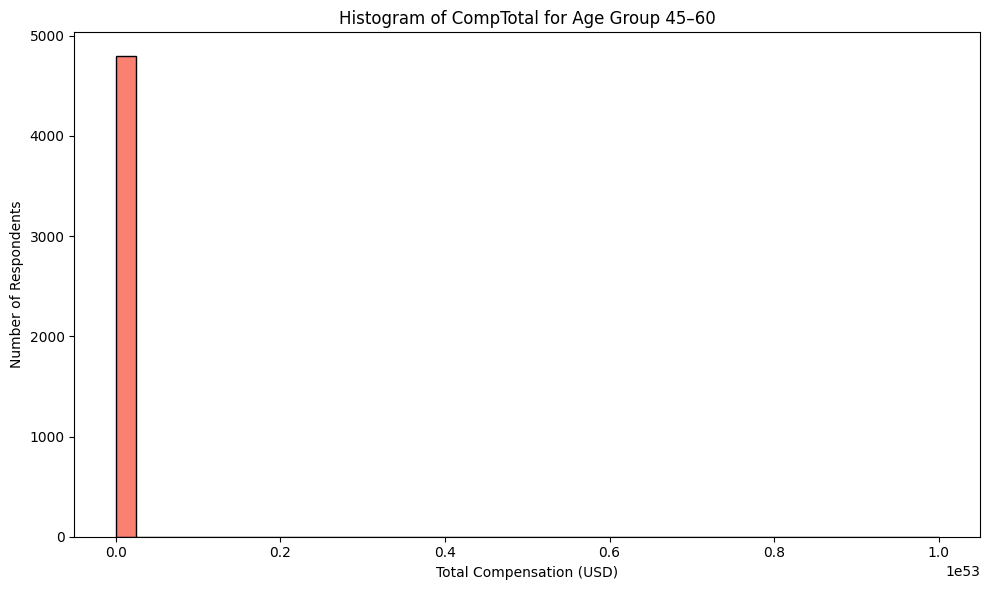

In [16]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Connect to SQLite database and load data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Map Age column to approximate numeric values
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}
df['AgeNumeric'] = df['Age'].map(age_map)

# Filter rows where Age is between 45 and 60
filtered_df = df[(df['AgeNumeric'] >= 45) & (df['AgeNumeric'] <= 60)]

# Drop missing compensation values
comp_data = filtered_df['CompTotal'].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(comp_data, bins=40, color='salmon', edgecolor='black')
plt.title('Histogram of CompTotal for Age Group 45–60')
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


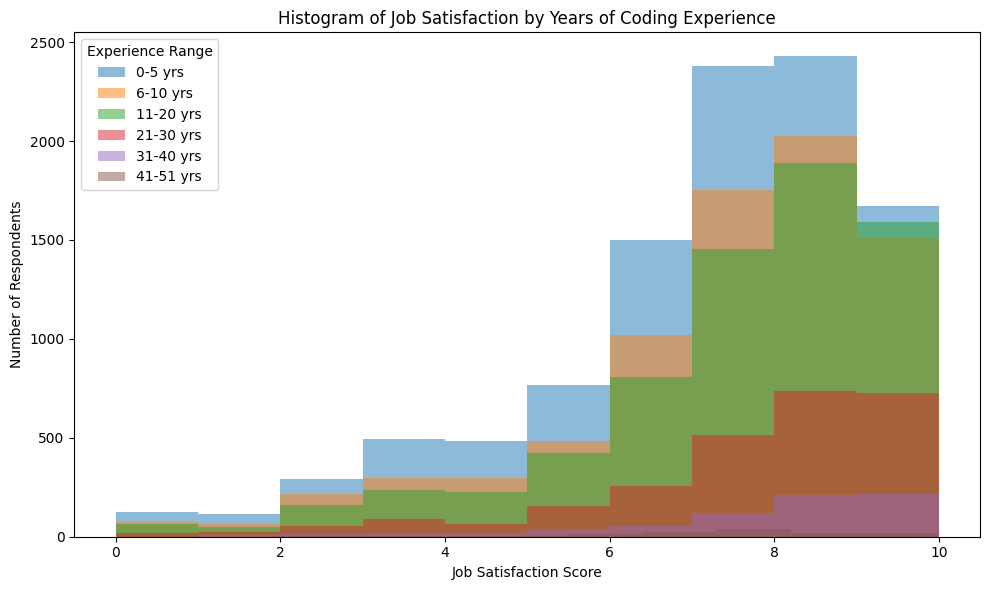

In [17]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Connect to SQLite and load dataset
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Clean and convert YearsCodePro to numeric
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
}).astype(float)

# Drop rows with missing values in YearsCodePro or JobSat
filtered_df = df[['YearsCodePro', 'JobSat']].dropna()

# Plot histogram of JobSat for different experience ranges
# Define experience bins
bins = [0, 5, 10, 20, 30, 40, 51]
labels = ['0-5', '6-10', '11-20', '21-30', '31-40', '41-51']
filtered_df['ExperienceRange'] = pd.cut(filtered_df['YearsCodePro'], bins=bins, labels=labels)

# Plot histogram
plt.figure(figsize=(10, 6))
for label in labels:
    subset = filtered_df[filtered_df['ExperienceRange'] == label]['JobSat']
    plt.hist(subset, bins=10, alpha=0.5, label=f'{label} yrs')

plt.title('Histogram of Job Satisfaction by Years of Coding Experience')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Number of Respondents')
plt.legend(title='Experience Range')
plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
